# préparation et extraction de features

In [28]:
from pathlib import Path
from PIL import Image
import numpy as np


In [29]:
def extraire_images(path):
    """ renvoie un tableau numpy contenant les images extraites du chemin donné """
    path_fichier_jpg = list(path.glob("*.jpg"))
    return np.array([np.array(Image.open(fichier)) for fichier in path_fichier_jpg])

In [31]:

# On définit les chemins
chemin_sans_label = Path("/home/arnaud/Code/Projet10/mri_dataset_brain_cancer_oc/sans_label")
chemin_normal = Path("/home/arnaud/Code/Projet10/mri_dataset_brain_cancer_oc/avec_labels/normal")
chemin_cancer = Path("/home/arnaud/Code/Projet10/mri_dataset_brain_cancer_oc/avec_labels/cancer")

# On récupère tous les fichiers png
images_sans_label = extraire_images(chemin_sans_label)
images_normal = extraire_images(chemin_normal)
images_cancer = extraire_images(chemin_cancer)

if len(images_sans_label) == 0 or len(images_normal) == 0 or len(images_cancer) == 0:
    print("Erreur : Aucun fichier trouvé dans l'un des dossiers.")

else:
    print(f"Succès : {len(images_sans_label)} images trouvées.")
    # On peut maintenant prendre la première en toute sécurité
    image_matrice = np.array(images_sans_label[0])     
    print(f"Forme de l'image : {image_matrice.shape}")


Succès : 1406 images trouvées.
Forme de l'image : (512, 512, 3)


In [32]:
def verifier_format_images(fichiers):
    """ verifie que toutes les images ont la même taille et le même nombre de canaux de couleur de base (512x512 pixels et 3 canaux) """
    memedimensions = True
    # On vérifie que toutes les images sont au même format
    for fichier in fichiers_png:
        image = Image.open(fichier)
        memeDimensions = true
        if np.array(image).shape != (512, 512, 3):
            print(f"Attention : L'image {fichier} a une taille différente : {image.size}")
            memedimensions = false
    if memedimensions:
        print("Toutes les images ont la même taille : 512x512 pixels et 3 canaux de couleur.")
    else:
        print("Il y a des images avec des tailles différentes. Veuillez vérifier les fichiers.")
    return memedimensions


In [33]:
# On vérifie que toutes les images sont bien au même format

verifier_format_images(images_sans_label)
verifier_format_images(images_normal)
verifier_format_images(images_cancer)

Toutes les images ont la même taille : 512x512 pixels et 3 canaux de couleur.
Toutes les images ont la même taille : 512x512 pixels et 3 canaux de couleur.
Toutes les images ont la même taille : 512x512 pixels et 3 canaux de couleur.


True

In [34]:
# Tailles de nos ensembles 
print(f"Nombre d'images sans label : {len(images_sans_label)}")
print(f"Nombre d'images normales : {len(images_normal)}")
print(f"Nombre d'images cancéreuses : {len(images_cancer)}")

Nombre d'images sans label : 1406
Nombre d'images normales : 50
Nombre d'images cancéreuses : 50


In [37]:
# Vérifications pour trouver des outliers
# -> On regroupe tout dans une même liste pour faire les vérifications d'un coup
toutes_les_images = np.concatenate([images_sans_label, images_normal, images_cancer])

# 1. On calcule la moyenne de CHAQUE image (le résultat sera une liste de 1506 moyennes)
moyennes_par_image = np.mean(toutes_les_images, axis=(1, 2, 3))

# 2. On calcule la moyenne et l'écart-type de ces 1506 valeurs
moyenne_des_moyennes = np.mean(moyennes_par_image)
ecart_type = np.std(moyennes_par_image)

print(f"Moyenne globale : {moyenne_des_moyennes}")
print(f"Écart-type global : {ecart_type}")

# 3. On calcule le "Z-score" (à combien d'écarts-types chaque image se trouve de la moyenne)
z_scores = np.abs((moyennes_par_image - moyenne_des_moyennes) / ecart_type)

# 4. On trouve les index des images qui dépassent le seuil de 3
index_outliers = np.where(z_scores > 3)[0]

print(f"Nombre d'outliers potentiels trouvés : {len(index_outliers)}")

Moyenne globale : 52.400531632861195
Écart-type global : 17.373623445055856
Nombre d'outliers potentiels trouvés : 14


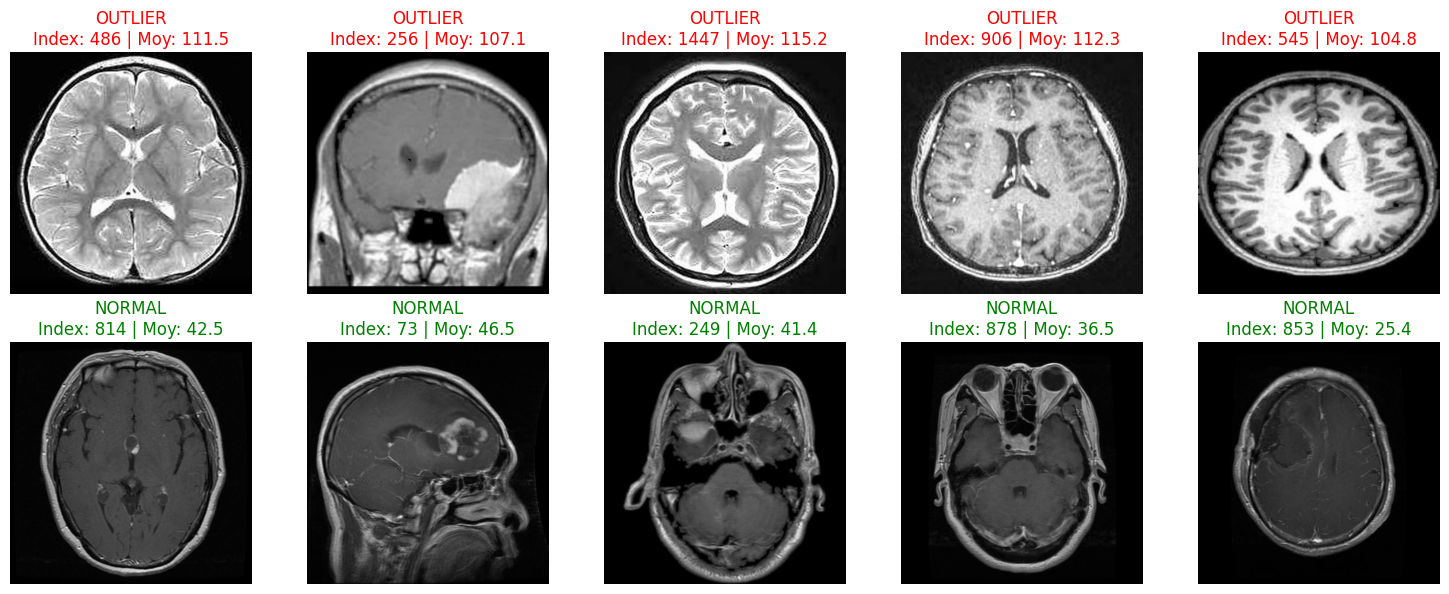

In [38]:
import matplotlib.pyplot as plt
import random

# 1. On liste tous les index "normaux" (ceux qui ne sont PAS dans tes 14 outliers)
tous_les_index = np.arange(len(toutes_les_images))
index_normaux = np.setdiff1d(tous_les_index, index_outliers)

# 2. On sélectionne un échantillon au hasard (ex: 5 images de chaque)
nb_a_afficher = 5
echantillon_outliers = random.sample(list(index_outliers), nb_a_afficher)
echantillon_normaux = random.sample(list(index_normaux), nb_a_afficher)

# 3. Création de la figure (2 lignes, 5 colonnes)
fig, axes = plt.subplots(nrows=2, ncols=nb_a_afficher, figsize=(15, 6))

# ---- LIGNE 1 : Affichage des Outliers ----
for i, idx in enumerate(echantillon_outliers):
    ax = axes[0, i]
    # On affiche l'image (si tes images sont en niveaux de gris, ajoute cmap='gray')
    ax.imshow(toutes_les_images[idx]) 
    
    # On ajoute un titre avec la valeur de la moyenne pour comprendre pourquoi c'est un outlier
    moyenne_img = moyennes_par_image[idx]
    ax.set_title(f"OUTLIER\nIndex: {idx} | Moy: {moyenne_img:.1f}", color='red')
    ax.axis('off') # On cache les axes (les graduations de pixels)

# ---- LIGNE 2 : Affichage des Normales ----
for i, idx in enumerate(echantillon_normaux):
    ax = axes[1, i]
    ax.imshow(toutes_les_images[idx])
    
    moyenne_img = moyennes_par_image[idx]
    ax.set_title(f"NORMAL\nIndex: {idx} | Moy: {moyenne_img:.1f}", color='green')
    ax.axis('off')

# Ajustement esthétique pour ne pas que les titres se chevauchent
plt.tight_layout()
plt.show()

Les outliers n'ont pas l'air d'être des erreurs mais juste des images plus clairs (peut-être due à un autre système d'imagerie ?)